# Threshold-free prediction and generalization

We compare annotation ranking and discrimination of operational P/N states. We check whether performance is stable across seeds and classes with different frequencies.

## Introduction

The analysis supports the selection of heads for subsequent experiments. We keep prediction quality, reconstruction and geometry separate. Definitions and limitations are described in [METHODOLOGY.md](METHODOLOGY.md), and execution instructions in [README.md](README.md).

### Assumptions

The evaluated pixels come from the saved partitions of one campaign; the result does not measure transfer to a new patient or acquisition. A positive annotation is an observed P; a missing annotation does not confirm the absence of a molecule. The unit of model comparison is the seed, not the pixel; duplicate tasks for the same condition and seed do not increase the number of repetitions. Candidate selection uses validation, while test provides subsequent confirmation.

### Notation

$X \in \mathbb{R}^{N\times M}$ denotes TIC-normalized spectra, $\hat X$ reconstructions, $Y \in \{0,1\}^{N\times C}$ annotations, and $A$ label availability. $Z=\mathrm{Enc}(X)$ is the latent representation used by the head and decoder; $U=(Z-\beta)/\gamma$ reverses the affine transformation of the final LayerNorm. Evidence states follow N=0, P=1, U=2; **state U and representation $U$ are different objects**. $s$ denotes the positive ranking score. $r$ is an independent training repetition.


In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_3_prediction_generalization_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 10:26:44,985 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 10:26:44,988 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 10:26:45,323 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 10:26:45,324 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 10:26:45,326 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 10:26:45,327 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Overall ranking and frequency dependence

### Methodology

#### Theoretical

AP is the sum of recall increments weighted by precision at successive distinct scores. ROC AUC is the probability of ranking P ahead of a comparison zero, with half credit for a tie. Macro is the mean over classes with P in train and both P and zeros in the evaluated partition.

#### Implementation

Binary heads: raw logit. CE: s=l_P-logsumexp(l_N,l_U), monotone in p_P. No sigmoid before sorting and no decision threshold. annotation_retrieval compares P with all available missing annotations; operational_pn compares only P with N under the common 0.0119/radius=1 rule. Rarity is determined exclusively from train: <10, 10–99, >=100 P.

#### Figure descriptions

x-axis: head; y-axis: AP. Each point is a seed after averaging identical duplicates; the violin includes all seeds. The per-class plot has the training P count on x and AP on y; colour identifies the head. Higher AP is better within the specified population.


2026-09-08 10:26:52,159 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:250 | Audited 65 model manifests across 2 sources.


,source,role,condition,label,repetition,initialization_seed,training_seed,data_contract,backbone_contract,training_contract,split,population,scope,metric,value,task_count,duplicate_min,duplicate_max
0,historical_bce,baseline,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,test,annotation_retrieval,frequent,ap_above_prevalence,0.729566,1,0.729566,0.729566
1,historical_bce,baseline,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,test,annotation_retrieval,frequent,average_precision,0.794027,1,0.794027,0.794027
2,historical_bce,baseline,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,test,annotation_retrieval,frequent,roc_auc,0.988785,1,0.988785,0.988785
3,historical_bce,baseline,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,test,annotation_retrieval,medium,ap_above_prevalence,0.303340,1,0.303340,0.303340
4,historical_bce,baseline,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),0,91154199,32238397,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,test,annotation_retrieval,medium,average_precision,0.304742,1,0.304742,0.304742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,predictive_initial,candidate,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,4,1915557887,1927548799,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,validation,operational_pn,rare,average_precision,0.702223,1,0.702223,0.702223
3236,predictive_initial,candidate,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,4,1915557887,1927548799,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,validation,operational_pn,rare,roc_auc,0.978987,1,0.978987,0.978987
3237,predictive_initial,candidate,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,4,1915557887,1927548799,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,validation,operational_pn,train_supported,ap_above_prevalence,0.725076,1,0.725076,0.725076
3238,predictive_initial,candidate,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,4,1915557887,1927548799,ff133cd42f7af414ee3022e7947f94bcd301e0ce338f93...,63d67af42e30038bef1fbb98125bd6ccad588380dabc4d...,a5d7efb7a6ea62831b16487e6675ffb395f704c73922c1...,validation,operational_pn,train_supported,average_precision,0.856557,1,0.856557,0.856557


2026-09-08 10:26:55,398 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 3 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_3_prediction_generalization_results.


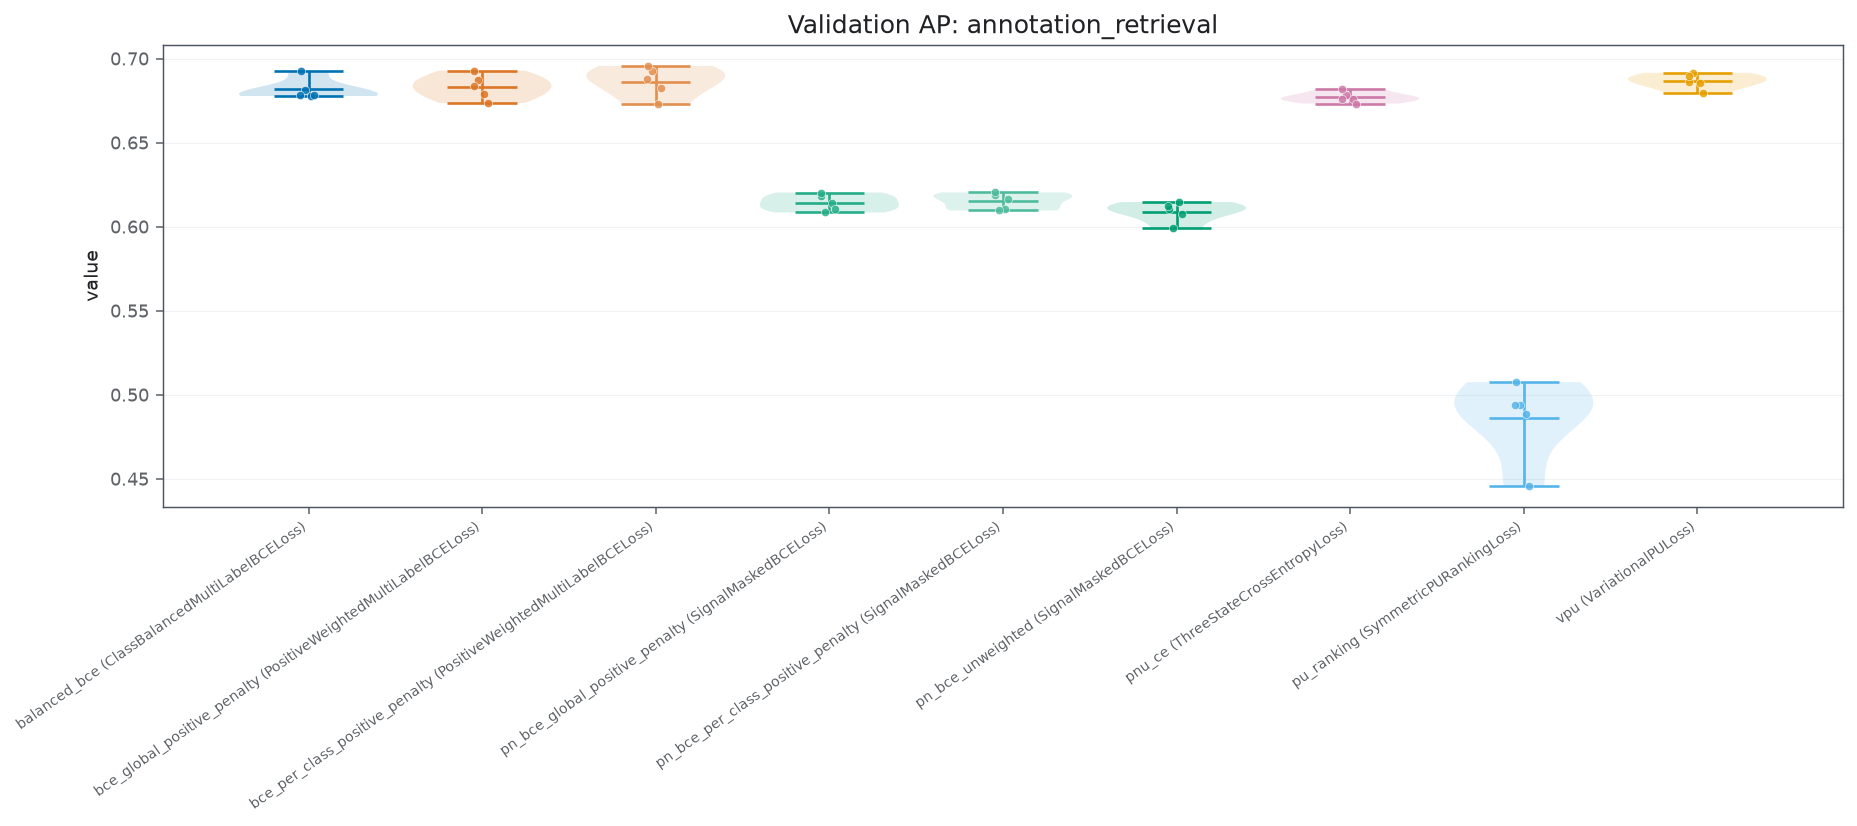

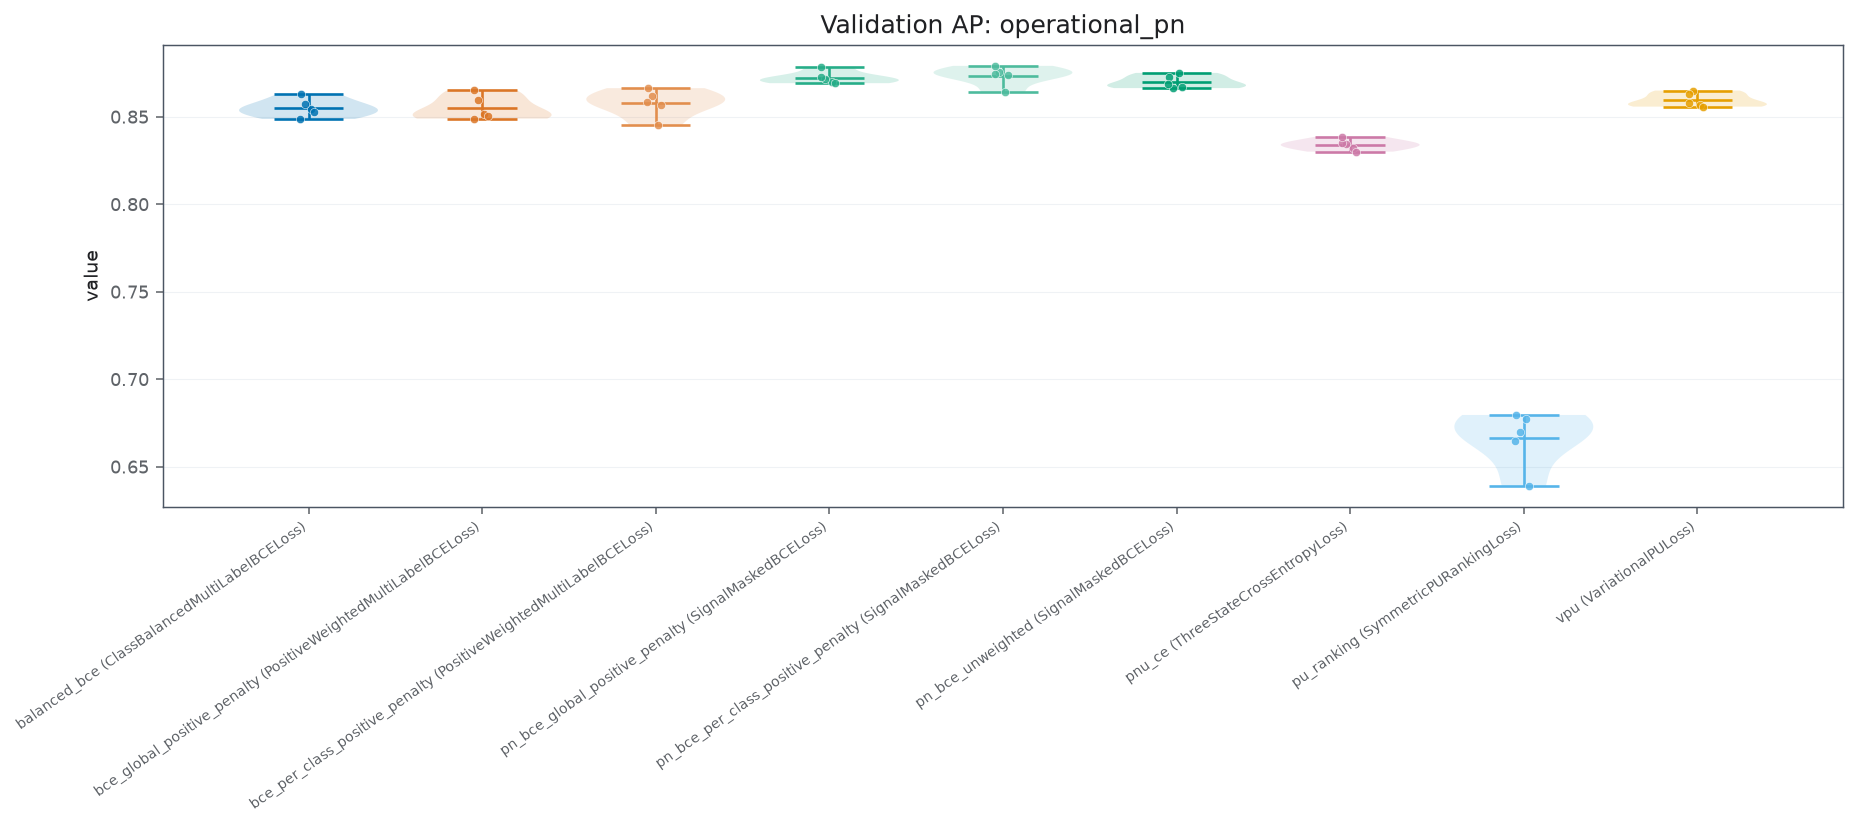

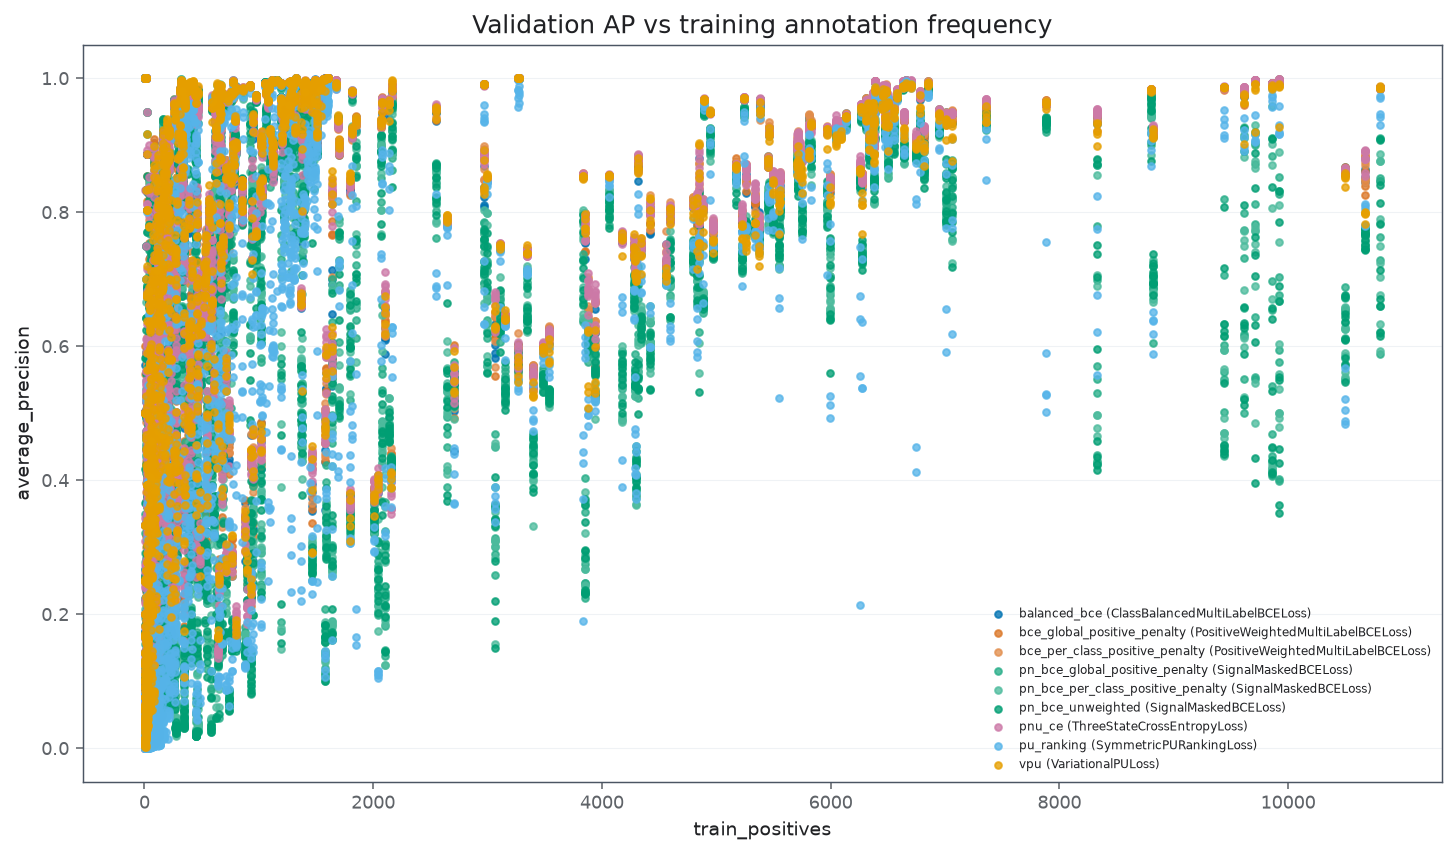

In [2]:
prediction = cache.load_table(settings, "prediction")
per_class = cache.load_table(settings, "per_class")
models, _ = campaign.inventory(settings)
keys = ["split", "population", "scope", "metric"]
units = reports.experimental_units(prediction, models, keys)
display(units)
for population in ["annotation_retrieval", "operational_pn"]:
    selected = units.query("split == 'validation' and scope == 'train_supported' and metric == 'average_precision' and population == @population")
    plots.distributions(selected, title=f"Validation AP: {population}").savefig(RESULTS / f"validation_{population}.png")
plots.scatter(per_class.query("split == 'validation' and population == 'annotation_retrieval'"), x="train_positives", y="average_precision", title="Validation AP vs training annotation frequency").savefig(RESULTS / "class_frequency.png")
reports.save_tables(RESULTS, prediction=prediction, per_class=per_class, experimental_units=units)

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Generalization gaps on common classes

### Methodology

#### Theoretical

The gap is mean AP_train-AP_held_out over the intersection of eligible classes in the two partitions for the same model and population. This prevents an apparent gap caused by different class sets; positive prevalence may still differ.

#### Implementation

Join per-class records by class_index, separately for validation and test. Compute the mean difference only after matching. Retain the number of compared classes for every model.

#### Figure descriptions

x-axis: head; y-axis: train-validation gap. A point represents a task; identical tasks may overlap. A positive gap means higher train performance, but a small gap alone does not establish good quality.


,model_id,population,held_out,metric,classes,train_value,held_out_value,value,label
0,historical_bce/task_000000,annotation_retrieval,validation,average_precision,508,0.665263,0.677801,-0.012538,balanced_bce (ClassBalancedMultiLabelBCELoss)
1,historical_bce/task_000000,annotation_retrieval,validation,roc_auc,508,0.990141,0.989524,0.000617,balanced_bce (ClassBalancedMultiLabelBCELoss)
2,historical_bce/task_000000,annotation_retrieval,test,average_precision,508,0.665263,0.669431,-0.004168,balanced_bce (ClassBalancedMultiLabelBCELoss)
3,historical_bce/task_000000,annotation_retrieval,test,roc_auc,508,0.990141,0.987947,0.002194,balanced_bce (ClassBalancedMultiLabelBCELoss)
4,historical_bce/task_000000,operational_pn,validation,average_precision,508,0.847162,0.854312,-0.007150,balanced_bce (ClassBalancedMultiLabelBCELoss)
...,...,...,...,...,...,...,...,...,...
515,predictive_initial/task_000059,annotation_retrieval,test,roc_auc,508,0.918580,0.918315,0.000266,pu_ranking (SymmetricPURankingLoss)
516,predictive_initial/task_000059,operational_pn,validation,average_precision,508,0.633894,0.639229,-0.005335,pu_ranking (SymmetricPURankingLoss)
517,predictive_initial/task_000059,operational_pn,validation,roc_auc,508,0.918607,0.917324,0.001283,pu_ranking (SymmetricPURankingLoss)
518,predictive_initial/task_000059,operational_pn,test,average_precision,508,0.633894,0.638698,-0.004805,pu_ranking (SymmetricPURankingLoss)


,state,quantity,quantile,value,entries,split,model_id,label,condition,repetition
0,P,positive_probability,0.0,0.000005,841771,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
1,P,positive_probability,0.1,0.766401,841771,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
2,P,positive_probability,0.5,0.977607,841771,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
3,P,positive_probability,0.9,0.998487,841771,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
4,P,positive_probability,1.0,1.000000,841771,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
...,...,...,...,...,...,...,...,...,...,...
5845,U,positive_log_odds,0.0,-51.856346,1216021,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
5846,U,positive_log_odds,0.1,-16.316734,1216021,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
5847,U,positive_log_odds,0.5,-11.379972,1216021,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
5848,U,positive_log_odds,0.9,-4.845095,1216021,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4


2026-09-08 10:26:58,839 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 2 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_3_prediction_generalization_results.


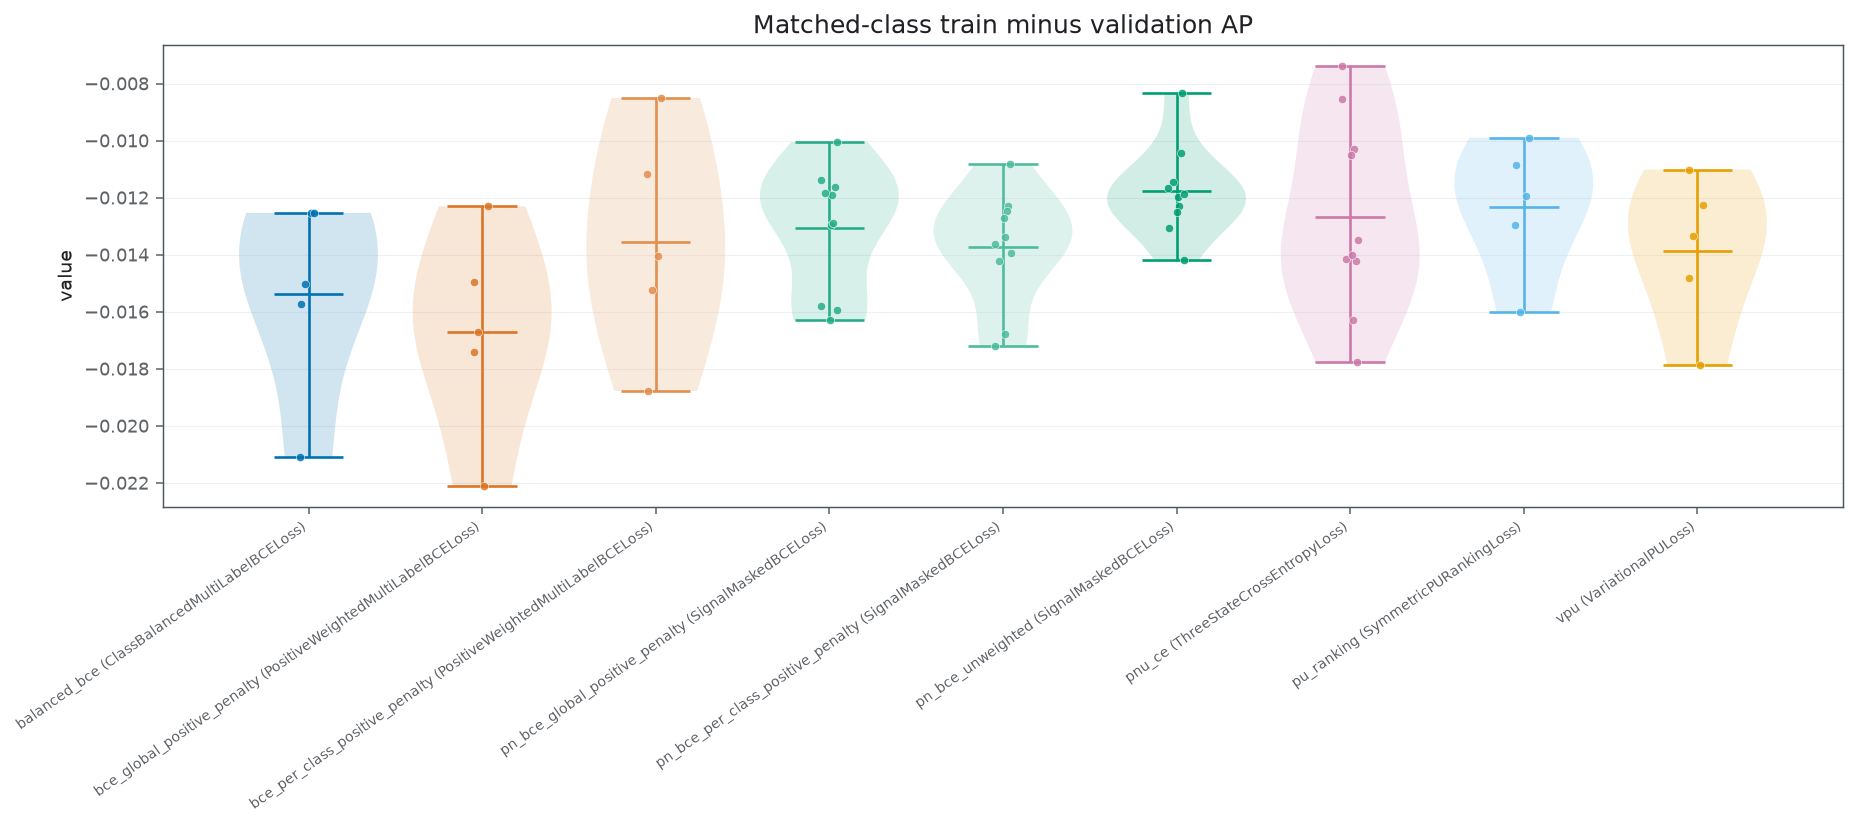

In [3]:
from msi_autoencoder_wrapper.analysis.autoencoder.heads.predictive_comparison import generalization_gaps

gaps = generalization_gaps(per_class)
gaps = gaps.merge(models[["model_id", "label"]], on="model_id", validate="many_to_one")
display(gaps)
plots.distributions(gaps.query("held_out == 'validation' and population == 'annotation_retrieval' and metric == 'average_precision'"), title="Matched-class train minus validation AP").savefig(RESULTS / "generalization_gap.png")
scores = cache.load_table(settings, "score_diagnostics")
display(scores)
reports.save_tables(RESULTS, generalization_gaps=gaps, score_diagnostics=scores)

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Results / Summary

### LLM

An executable protocol and table exports have been prepared. Results from the target campaign are not yet available; this file does not contain an empirical conclusion that any head is superior. After execution, assess effect direction and magnitude, variation across seeds, completeness of pairs and limitations of the label definitions.

### Person
